# Data Pre-processing and input taking

In [ ]:
import pandas as pd
import numpy as np
import re
country_name =str(input("Enter the country name: "))
target_year =int(input("Enter year(2019-Future):"))
file_path = '/content/historical_emissions.csv'
data = pd.read_csv(file_path)
data.head(), data.info()

Enter the country name: Bangladesh
Enter year(2019-Future):2026
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 34 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Country      195 non-null    object 
 1   Data source  195 non-null    object 
 2   Sector       195 non-null    object 
 3   Gas          195 non-null    object 
 4   Unit         195 non-null    object 
 5   2018         195 non-null    float64
 6   2017         195 non-null    float64
 7   2016         195 non-null    float64
 8   2015         195 non-null    float64
 9   2014         195 non-null    float64
 10  2013         195 non-null    float64
 11  2012         195 non-null    float64
 12  2011         195 non-null    float64
 13  2010         195 non-null    float64
 14  2009         195 non-null    float64
 15  2008         195 non-null    float64
 16  2007         195 non-null    float64
 17  2006         195 non-null   

(               Country Data source                Sector  Gas    Unit  \
 0                World        CAIT  Total including LUCF  CO2  MtCO₂e   
 1                China        CAIT  Total including LUCF  CO2  MtCO₂e   
 2        United States        CAIT  Total including LUCF  CO2  MtCO₂e   
 3  European Union (27)        CAIT  Total including LUCF  CO2  MtCO₂e   
 4                India        CAIT  Total including LUCF  CO2  MtCO₂e   
 
        2018      2017      2016      2015      2014  ...      1999      1998  \
 0  36441.55  35588.70  35160.60  34521.91  34558.59  ...  24957.30  24895.32   
 1   9663.36   9367.67   9164.21   9120.27   9184.77  ...   2799.84   2882.75   
 2   4749.57   4581.90   4656.84   4563.52   4683.35  ...   5191.66   5172.06   
 3   2636.99   2692.12   2669.54   2321.61   2263.78  ...   3079.46   3134.03   
 4   2400.25   2267.16   2149.01   2085.38   2072.03  ...    683.00    618.73   
 
        1997      1996      1995      1994      1993      1992    

In [ ]:
import pandas as pd

# Load dataset
input_path = "CCS Map Data Jan2023(Map Data).csv"
output_path = "CCS_Map_Data_Filled_Combustion_Separation.csv"

df = pd.read_csv(input_path, encoding="latin1")

def classify_combustion_separation(capture_tech):
    if pd.isna(capture_tech):
        return "Unknown / Not Specified"

    tech = capture_tech.lower()

    # Oxy-fuel combustion
    if "oxy" in tech:
        return "Oxy-fuel Combustion"

    # Pre-combustion / separation (gasification & syngas routes)
    pre_combustion_keywords = [
        "gasification", "igcc", "trig", "prenflo",
        "rectisol", "selexol", "cold methanol",
        "controlled freeze zone", "cfz",
        "hydrogen", "syngas"
    ]
    if any(k in tech for k in pre_combustion_keywords):
        return "Pre-combustion / Separation"

    # Post-combustion capture
    post_combustion_keywords = [
        "amine", "mea", "mdea", "ks-1",
        "solvent", "absorption", "econamine",
        "cansolv", "chilled ammonia",
        "solid sorbent", "sorbent",
        "membrane"
    ]
    if any(k in tech for k in post_combustion_keywords):
        return "Post-combustion"

    # Non-combustion separation
    separation_keywords = [
        "cryogenic", "gas separation",
        "natural gas", "air capture"
    ]
    if any(k in tech for k in separation_keywords):
        return "Separation"

    return "Unknown / Not Specified"

# Fill only missing values
df["Combustion / Separation"] = df["Combustion / Separation"].fillna(
    df["Capture Technology"].apply(classify_combustion_separation)
)

# Save completed CSV
df.to_csv(output_path, index=False)

print("Completed file saved as:", output_path)


In [ ]:
data = data.reset_index(drop=True)  #The index is reseted to ensure proper drop
dropped_row_index = 0  # This index is dropped
data = data.drop(index=dropped_row_index).reset_index(drop=True)

columns_to_keep = ["Country"] + [str(year) for year in range(1990, 2019)]
filtered_data = data[columns_to_keep]

long_format = filtered_data.melt(id_vars=["Country"],
                                 var_name="Year",
                                 value_name="Emission")

long_format["Year"] = long_format["Year"].astype(int)
long_format["Emission"] = pd.to_numeric(long_format["Emission"], errors='coerce')

long_format.dropna(inplace=True) #Null value handled

long_format.head(), long_format.info()


<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 0 to 5625
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Country   5625 non-null   object 
 1   Year      5625 non-null   int64  
 2   Emission  5625 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 175.8+ KB


(               Country  Year  Emission
 0                China  1990   1823.96
 1        United States  1990   4426.40
 2  European Union (27)  1990   3286.44
 3                India  1990    341.32
 4            Indonesia  1990    832.39,
 None)

# Prophet Model

In [ ]:
!pip install prophet -q

In [ ]:
import joblib
from prophet import Prophet
from pathlib import Path
import pandas as pd
from sklearn.metrics import mean_absolute_error

scaler = MinMaxScaler()

def prepare_data_for_prophet(country_name, data):
    country_data = data[data["Country"] == country_name].sort_values("Year")

    prophet_data = country_data[["Year", "Emission"]].rename(columns={"Year": "ds", "Emission": "y"})
    prophet_data["ds"] = pd.to_datetime(prophet_data["ds"], format='%Y')  # year to datetime conversion
    return prophet_data

def train_and_save_prophet_model(country_name, data, save_path="prophet_models"):
    prophet_data = prepare_data_for_prophet(country_name, data)

    if prophet_data.shape[0] < 2:
        raise ValueError(f"Insufficient data for {country_name}. At least 2 data points are required.")

    prophet_data["y"] = scaler.fit_transform(prophet_data[["y"]])

    train_size = int(len(prophet_data) * 0.8)
    train_data = prophet_data.iloc[:train_size]
    val_data = prophet_data.iloc[train_size:]

    model = Prophet()
    model.fit(train_data)

    future = model.make_future_dataframe(periods=len(val_data), freq='Y')
    forecast = model.predict(future)

    val_forecast = forecast[-len(val_data):]

    mae = mean_absolute_error(val_data["y"], val_forecast["yhat"])

    Path(save_path).mkdir(parents=True, exist_ok=True)
    model_path = f"{save_path}/{country_name}_prophet_model.pkl"
    joblib.dump(model, model_path)

    return mae

def load_prophet_model(country_name, save_path="prophet_models"):
    model_path = f"{save_path}/{country_name}_prophet_model.pkl"
    if not Path(model_path).is_file():
        raise FileNotFoundError(f"Model for {country_name} not found.")

    model = joblib.load(model_path)

    return model

def predict_with_saved_prophet_model(country_name, target_year, model):
    max_year = model.history["ds"].dt.year.max()

    periods = target_year - max_year
    if periods <= 0:
        raise ValueError(f"Target year {target_year} is already in the training data.")

    future = model.make_future_dataframe(periods=periods, freq='Y')

    while future["ds"].dt.year.max() < target_year:
        periods += 1
        future = model.make_future_dataframe(periods=periods, freq='Y')

    forecast = model.predict(future)

    target_forecast = forecast[forecast["ds"].dt.year == target_year]
    if target_forecast.empty:
        raise ValueError(f"No forecast available for the target year {target_year}.")

    predicted_value = target_forecast["yhat"].values[0]

    predicted_value = scaler.inverse_transform([[predicted_value]])[0][0]

    return predicted_value

In [ ]:
try:
    prophet_mae = train_and_save_prophet_model(country_name, long_format)

    prophet_model = load_prophet_model(country_name)

    prophet_prediction = predict_with_saved_prophet_model(country_name, target_year, prophet_model)
    print(f"Prophet Predicted Carbon Emission for {country_name} in {target_year}: {prophet_prediction} MtCO2")

except Exception as e:
    print(f"Error: {e}")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 17.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl5py6jwd/lwcy0vcb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpl5py6jwd/8ozk3v_5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=45954', 'data', 'file=/tmp/tmpl5py6jwd/lwcy0vcb.json', 'init=/tmp/tmpl5py6jwd/8ozk3v_5.json', 'output', 'file=/tmp/tmpl5py6jwd/prophet_modelfknrgy6z/prophet_model-20250621160206.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
16:02:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:02:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:

Prophet Predicted Carbon Emission for Bangladesh in 2026: 131.9087167106931 MtCO2


/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


# ARIMA Model

In [ ]:
!pip install statsmodels -q

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
import joblib
from pathlib import Path

scaler = MinMaxScaler(feature_range=(0, 1))

def prepare_data_for_arima(country_name, data):
    country_data = data[data["Country"] == country_name].sort_values("Year")
    return country_data["Emission"].values

def train_and_save_arima_model(country_name, data, save_path="arima_models"):
    emissions = prepare_data_for_arima(country_name, data)

    emissions_normalized = scaler.fit_transform(emissions.reshape(-1, 1)).flatten()

    split_index = int(len(emissions_normalized) * 0.8)
    train_data = emissions_normalized[:split_index]
    val_data = emissions_normalized[split_index:]

    model = ARIMA(train_data, order=(5, 1, 0))
    fitted_model = model.fit()

    Path(save_path).mkdir(parents=True, exist_ok=True)
    model_path = f"{save_path}/{country_name}_arima_model.pkl"
    joblib.dump(fitted_model, model_path)
    print(f"ARIMA model for {country_name} saved to {model_path}.")

    forecast_steps = len(val_data)
    forecast = fitted_model.forecast(steps=forecast_steps)
    mae = mean_absolute_error(val_data, forecast)

    return mae

def load_arima_model(country_name, save_path="arima_models"):
    model_path = f"{save_path}/{country_name}_arima_model.pkl"
    if not Path(model_path).is_file():
        raise FileNotFoundError(f"Model for {country_name} not found.")

    model = joblib.load(model_path)
    print(f"ARIMA model for {country_name} loaded from {model_path}.")
    return model

def predict_with_arima_model(country_name, target_year, data, model):
    emissions = prepare_data_for_arima(country_name, data)
    start_year = data[data["Country"] == country_name]["Year"].min()
    max_year = data[data["Country"] == country_name]["Year"].max()

    steps = target_year - max_year
    if steps <= 0:
        raise ValueError(f"Target year {target_year} is already in the training data.")

    forecast = model.forecast(steps=steps)
    predicted_value = forecast[-1]

    predicted_value = scaler.inverse_transform([[predicted_value]])[0][0]

    return predicted_value


In [ ]:
arima_mae = train_and_save_arima_model(country_name, long_format)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


ARIMA model for Bangladesh saved to arima_models/Bangladesh_arima_model.pkl.


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
try:
    arima_model = load_arima_model(country_name)
    arima_prediction = predict_with_arima_model(country_name, target_year, long_format, arima_model)
    print(f"ARIMA Predicted Carbon Emission for {country_name} in {target_year}: {arima_prediction} MtCO2")
except Exception as e:
    print(f"Error: {e}")


ARIMA model for Bangladesh loaded from arima_models/Bangladesh_arima_model.pkl.
ARIMA Predicted Carbon Emission for Bangladesh in 2026: 106.97234690171862 MtCO2


# SARIMA Model

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib
from pathlib import Path
from sklearn.metrics import mean_absolute_error

def prepare_data_for_sarima(country_name, data):
    country_data = data[data["Country"] == country_name].sort_values("Year")
    return country_data["Emission"].values

def train_and_save_sarima_model(country_name, data, save_path="sarima_models"):
    emissions = prepare_data_for_sarima(country_name, data)

    emissions_normalized = scaler.fit_transform(emissions.reshape(-1, 1)).flatten()

    split_index = int(len(emissions_normalized) * 0.8)
    train_data = emissions_normalized[:split_index]
    val_data = emissions_normalized[split_index:]

    order = (5, 1, 0)
    seasonal_order = (1, 1, 1, 12)

    model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order)
    fitted_model = model.fit()

    Path(save_path).mkdir(parents=True, exist_ok=True)
    model_path = f"{save_path}/{country_name}_sarima_model.pkl"
    joblib.dump(fitted_model, model_path)
    print(f"SARIMA model for {country_name} saved to {model_path}.")

    forecast_steps = len(val_data)
    forecast = fitted_model.get_forecast(steps=forecast_steps)
    mae = mean_absolute_error(val_data, forecast.predicted_mean)

    return mae

def load_sarima_model(country_name, save_path="sarima_models"):
    model_path = f"{save_path}/{country_name}_sarima_model.pkl"
    if not Path(model_path).is_file():
        raise FileNotFoundError(f"Model for {country_name} not found.")

    model = joblib.load(model_path)
    print(f"SARIMA model for {country_name} loaded from {model_path}.")
    return model

In [ ]:
def predict_with_sarima_model(country_name, target_year, data, model):
    emissions = prepare_data_for_sarima(country_name, data)
    start_year = data[data["Country"] == country_name]["Year"].min()
    max_year = data[data["Country"] == country_name]["Year"].max()

    steps = target_year - max_year
    if steps <= 0:
        raise ValueError(f"Target year {target_year} is already in the training data.")

    forecast = model.get_forecast(steps=steps)
    predicted_value = forecast.predicted_mean[-1]

    predicted_value = scaler.inverse_transform([[predicted_value]])[0][0]

    return predicted_value

In [ ]:
sarima_mae = train_and_save_sarima_model(country_name, long_format)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA model for Bangladesh saved to sarima_models/Bangladesh_sarima_model.pkl.


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
try:
    sarima_model = load_sarima_model(country_name)
    sarima_prediction = predict_with_sarima_model(country_name, target_year, long_format, sarima_model)
    print(f"SARIMA Predicted Carbon Emission for {country_name} in {target_year}: {sarima_prediction} MtCO2")
except Exception as e:
    print(f"Error: {e}")

SARIMA model for Bangladesh loaded from sarima_models/Bangladesh_sarima_model.pkl.
SARIMA Predicted Carbon Emission for Bangladesh in 2026: 116.26593929840527 MtCO2


# LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

lstm_history = lstm_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

lstm_model.summary()

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0044 - mae: 0.0230 - val_loss: 4.6865e-04 - val_mae: 0.0059
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.5957e-04 - mae: 0.0094 - val_loss: 1.2133e-04 - val_mae: 0.0045
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5601e-04 - mae: 0.0058 - val_loss: 1.6749e-04 - val_mae: 0.0052
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2497e-04 - mae: 0.0044 - val_loss: 1.1806e-04 - val_mae: 0.0075
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0871e-04 - mae: 0.0041 - val_loss: 1.5266e-04 - val_mae: 0.0044
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6653e-04 - mae: 0.0048 - val_loss: 8.0259e-05 - val_mae: 0.0023
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2156e-04 - mae: 0.0041 - val_loss: 7.7653e-05 - val_mae: 0.0033
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8020e-04 - mae: 0.0045 - val_loss: 9.7956e-05 - val_mae: 0.0041
Epoch 9

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,105 (137.13 KB)

 Trainable params: 11,701 (45.71 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 23,404 (91.43 KB)

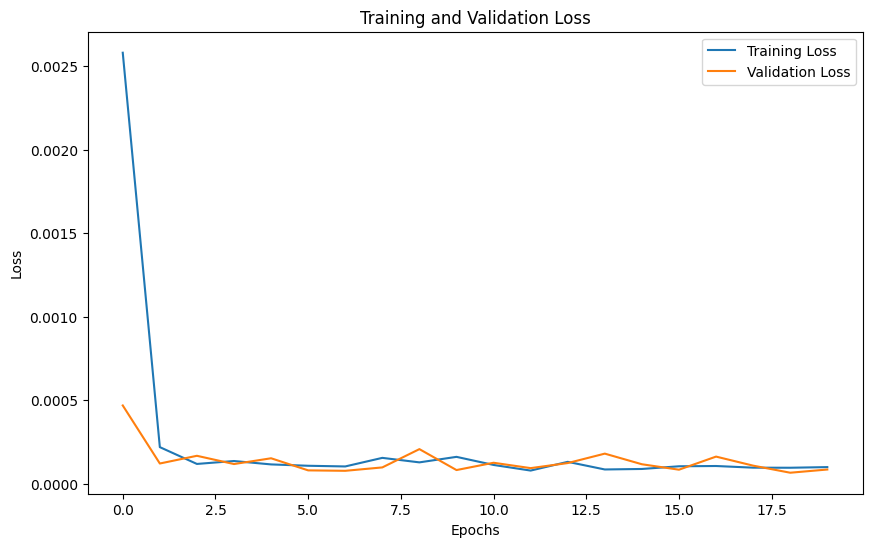

In [ ]:
import matplotlib.pyplot as plt

lstm_train_loss = lstm_history.history['loss']
lstm_val_loss = lstm_history.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(lstm_train_loss, label='Training Loss')
plt.plot(lstm_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
lstm_test_loss, lstm_test_mae = lstm_model.evaluate(X_test_reshaped, y_test, verbose=1)

print(f"Test Loss: {lstm_test_loss}, Test MAE: {lstm_test_mae}")

# model.save("carbon_emission_lstm_model.h5")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1069e-05 - mae: 0.0030 
Test Loss: 2.7568024961510673e-05, Test MAE: 0.00301743415184319


In [ ]:
def predict_emission_recursive_lstm(country_name, target_year, data, model, scaler, sequence_length=3):

    country_data = data[data["Country"] == country_name].sort_values("Year")

    available_years = country_data["Year"].values
    emissions = country_data["Emission"].values

    if len(available_years) < sequence_length:
        raise ValueError(f"Insufficient data for {country_name} to make predictions.")

    normalized_emissions = scaler.transform(emissions.reshape(-1, 1)).flatten()

    current_year = max(available_years)
    while current_year < target_year:
        input_sequence = normalized_emissions[-sequence_length:].reshape(1, sequence_length, 1)

        next_normalized_emission = model.predict(input_sequence).flatten()[0]

        normalized_emissions = np.append(normalized_emissions, next_normalized_emission)

        current_year += 1
        available_years = np.append(available_years, current_year)

    predicted_normalized_emission = normalized_emissions[-1]
    predicted_emission = scaler.inverse_transform([[predicted_normalized_emission]]).flatten()[0]

    return predicted_emission

In [ ]:
try:
    predicted_emission = predict_emission_recursive_lstm(
        country_name, target_year, long_format, lstm_model, scaler, sequence_length=3
    )
    print(f"Predicted Carbon Emission for {country_name} in {target_year}: {predicted_emission} MtCO2")
except ValueError as e:
    print(e)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted Carbon Emission for Bangladesh in 2026: 107.11321405649186 MtCO2


# Bi-LSTM Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout

bi_lstm_model = Sequential([
    Bidirectional(LSTM(50, activation='relu', return_sequences=False), input_shape=(X_train.shape[1], 1)),  # Bidirectional LSTM layer
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

bi_lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

bi_lstm_history = bi_lstm_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

bi_lstm_model.summary()


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0030 - mae: 0.0197 - val_loss: 1.8963e-04 - val_mae: 0.0053
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.3715e-04 - mae: 0.0070 - val_loss: 1.2370e-04 - val_mae: 0.0032
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.4384e-05 - mae: 0.0045 - val_loss: 1.1180e-04 - val_mae: 0.0033
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.1553e-05 - mae: 0.0041 - val_loss: 7.1922e-05 - val_mae: 0.0032
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1801e-04 - mae: 0.0040 - val_loss: 8.4338e-05 - val_mae: 0.0046
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1955e-04 - mae: 0.0045 - val_loss: 4.9313e-05 - val_mae: 0.0015
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1582e-04 - mae: 0.0044 - val_loss: 1.2207e-04 - val_mae: 0.0021
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.1105e-05 - mae: 0.0034 - val_loss: 6.3684e-05 - val_mae: 0.0038
Epoch 9

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 100)            │        20,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 70,055 (273.66 KB)

 Trainable params: 23,351 (91.21 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 46,704 (182.44 KB)

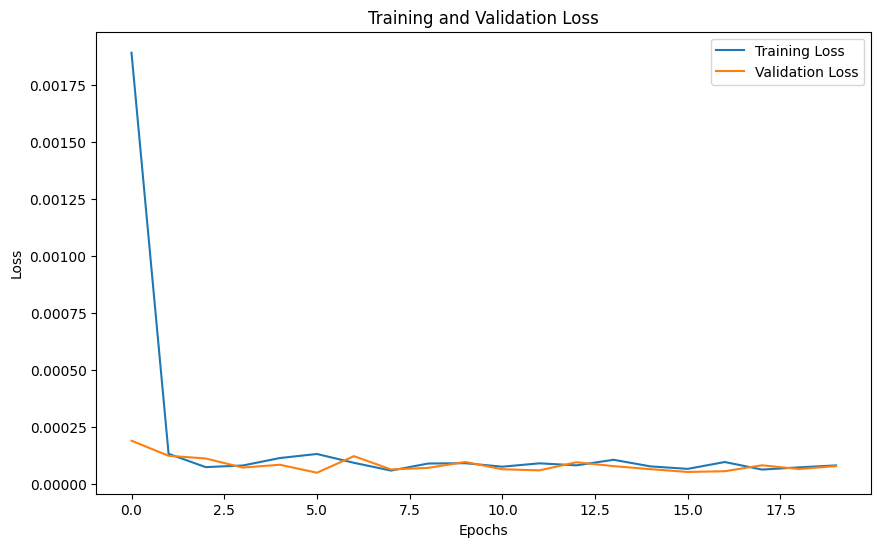

In [ ]:
import matplotlib.pyplot as plt

bilstm_train_loss = bi_lstm_history.history['loss']
bilstm_val_loss = bi_lstm_history.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(bilstm_train_loss, label='Training Loss')
plt.plot(bilstm_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
lstm_test_loss, lstm_test_mae = lstm_model.evaluate(X_test_reshaped, y_test, verbose=1)

print(f"Test Loss: {lstm_test_loss}, Test MAE: {lstm_test_mae}")



26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1069e-05 - mae: 0.0030
Test Loss: 2.7568024961510673e-05, Test MAE: 0.00301743415184319


In [ ]:
bi_lstm_test_loss, bi_lstm_test_mae = bi_lstm_model.evaluate(X_test_reshaped, y_test, verbose=1)
print(f"Test Loss: {bi_lstm_test_loss}, Test MAE: {bi_lstm_test_mae}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.6121e-05 - mae: 0.0050
Test Loss: 4.4083291868446395e-05, Test MAE: 0.005126043222844601


In [ ]:
def predict_emission_recursive_bilstm(country_name, target_year, data, model, scaler, sequence_length=3):

    country_data = data[data["Country"] == country_name].sort_values("Year")

    available_years = country_data["Year"].values
    emissions = country_data["Emission"].values

    if len(available_years) < sequence_length:
        raise ValueError(f"Insufficient data for {country_name} to make predictions.")

    normalized_emissions = scaler.transform(emissions.reshape(-1, 1)).flatten()

    current_year = max(available_years)
    while current_year < target_year:
        input_sequence = normalized_emissions[-sequence_length:].reshape(1, sequence_length, 1)

        next_normalized_emission = model.predict(input_sequence).flatten()[0]

        normalized_emissions = np.append(normalized_emissions, next_normalized_emission)

        current_year += 1
        available_years = np.append(available_years, current_year)

    predicted_normalized_emission = normalized_emissions[-1]
    predicted_emission = scaler.inverse_transform([[predicted_normalized_emission]]).flatten()[0]

    return predicted_emission

In [ ]:
try:
    predicted_emission_bilstm = predict_emission_recursive_bilstm(
        country_name, target_year, long_format, bi_lstm_model, scaler, sequence_length=3
    )
    print(f"Predicted Carbon Emission for {country_name} in {target_year}: {predicted_emission_bilstm} MtCO2")
except ValueError as e:
    print(e)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Carbon Emission for Bangladesh in 2026: 127.46940348148347 MtCO2


# GRU Model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.models import Sequential

gru_model = Sequential([
    GRU(50, activation='relu', input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dropout(0.2),
    Dense(25, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

gru_model.summary()

gru_history = gru_model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 50)             │         7,950 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,251 (36.14 KB)

 Trainable params: 9,251 (36.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0043 - mae: 0.0228 - val_loss: 7.5070e-04 - val_mae: 0.0040
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.4143e-04 - mae: 0.0099 - val_loss: 8.8374e-05 - val_mae: 0.0028
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4331e-04 - mae: 0.0045 - val_loss: 8.7789e-05 - val_mae: 0.0028
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.6547e-04 - mae: 0.0051 - val_loss: 1.4285e-04 - val_mae: 0.0054
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4488e-04 - mae: 0.0047 - val_loss: 1.2795e-04 - val_mae: 0.0028
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.3578e-04 - mae: 0.0044 - val_loss: 7.1400e-05 - val_mae: 0.0030
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.1545e-04 - mae: 0.0043 - val_loss: 5.8712e-05 - val_mae: 0.0042
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.0350e-04 - mae: 0.0042 - val_loss: 1.5618e-04 - val_mae: 0.0

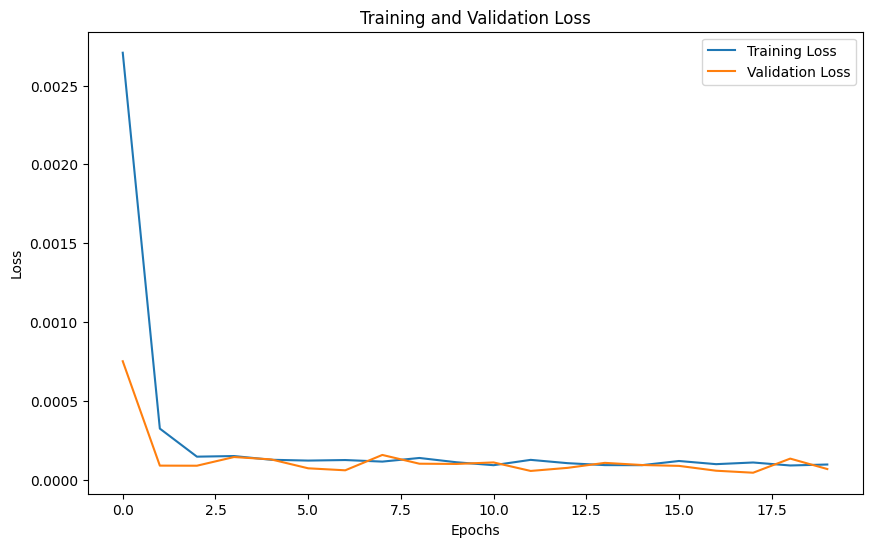

In [ ]:
gru_train_loss = gru_history.history['loss']
gru_val_loss = gru_history.history['val_loss']

plt.figure(figsize=(10, 6))
plt.plot(gru_train_loss, label='Training Loss')
plt.plot(gru_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
gru_test_loss, gru_test_mae = gru_model.evaluate(X_test_reshaped, y_test, verbose=1)
print(f"Test Loss: {gru_test_loss}, Test MAE: {gru_test_mae}")

def predict_emission_recursive_gru(country_name, target_year, data, model, scaler, sequence_length=3):

    country_data = data[data["Country"] == country_name].sort_values("Year")

    available_years = country_data["Year"].values
    emissions = country_data["Emission"].values

    if len(available_years) < sequence_length:
        raise ValueError(f"Insufficient data for {country_name} to make predictions.")

    normalized_emissions = scaler.transform(emissions.reshape(-1, 1)).flatten()

    current_year = max(available_years)
    while current_year < target_year:
        input_sequence = normalized_emissions[-sequence_length:].reshape(1, sequence_length, 1)

        next_normalized_emission = model.predict(input_sequence).flatten()[0]

        normalized_emissions = np.append(normalized_emissions, next_normalized_emission)

        current_year += 1
        available_years = np.append(available_years, current_year)

    predicted_normalized_emission = normalized_emissions[-1]
    predicted_emission = scaler.inverse_transform([[predicted_normalized_emission]]).flatten()[0]

    return predicted_emission

try:
    predicted_emission_gru = predict_emission_recursive_gru(
        country_name, target_year, long_format, gru_model, scaler, sequence_length=3
    )
    print(f"Predicted Carbon Emission for {country_name} in {target_year}: {predicted_emission_gru} MtCO2")
except ValueError as e:
  print(e)


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6567e-05 - mae: 0.0020
Test Loss: 2.117643271049019e-05, Test MAE: 0.002072555013000965
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Predicted Carbon Emission for Bangladesh in 2026: 114.78946734428406 MtCO2


# Comparing Models

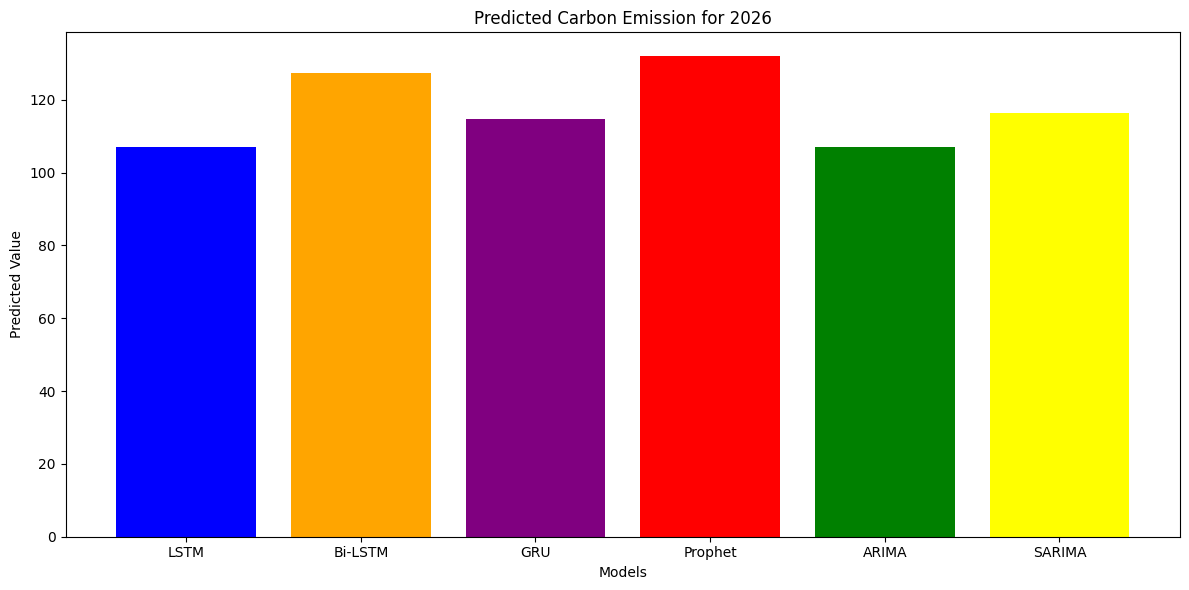

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

models = ["LSTM","Bi-LSTM", "GRU", "Prophet", "ARIMA","SARIMA"]
predictions = [predicted_emission, predicted_emission_bilstm, predicted_emission_gru, prophet_prediction, arima_prediction,sarima_prediction]

plt.figure(figsize=(12, 6))
plt.bar(models, predictions, color=["blue", "orange", "purple", "red","green","yellow"])
plt.title(f"Predicted Carbon Emission for {target_year}")
plt.ylabel("Predicted Value")
plt.xlabel("Models")

plt.tight_layout()
plt.show()


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  


/usr/local/lib/python3.11/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


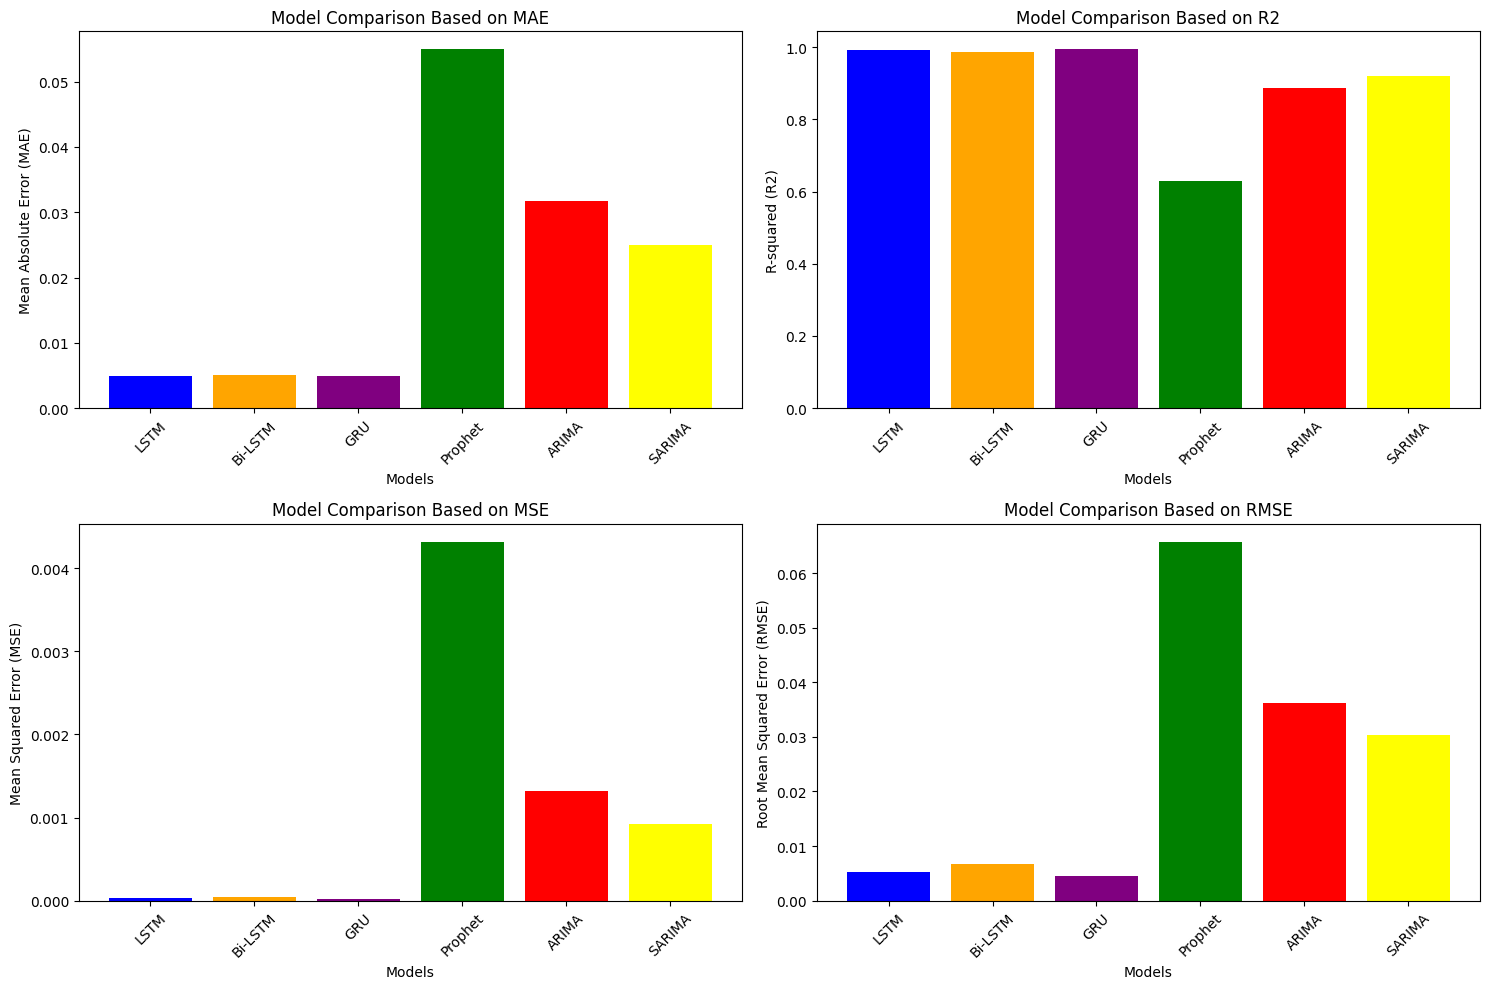


Model Performance Metrics:
LSTM: MAE=0.0049, R2=0.9925, MSE=0.000028, RMSE=0.0053
Bi-LSTM: MAE=0.0051, R2=0.9881, MSE=0.000044, RMSE=0.0066
GRU: MAE=0.0049, R2=0.9943, MSE=0.000021, RMSE=0.0046
Prophet: MAE=0.0550, R2=0.6302, MSE=0.004319, RMSE=0.0657
ARIMA: MAE=0.0317, R2=0.8874, MSE=0.001316, RMSE=0.0363
SARIMA: MAE=0.0249, R2=0.9214, MSE=0.000918, RMSE=0.0303


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_values = {
    "LSTM": np.mean(lstm_history.history['mae']),
    "Bi-LSTM": bi_lstm_test_mae,
    "GRU": np.mean(gru_history.history['mae']),
    "Prophet": prophet_mae,
    "ARIMA": arima_mae,
    "SARIMA": sarima_mae
}

# Calculation of  R2, MSE, and RMSE for all models
lstm_predictions = lstm_model.predict(X_test_reshaped)
bi_lstm_predictions = bi_lstm_model.predict(X_test_reshaped)
gru_predictions = gru_model.predict(X_test_reshaped)

lstm_r2 = r2_score(y_test, lstm_predictions)
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(lstm_mse)

bi_lstm_r2 = r2_score(y_test, bi_lstm_predictions)
bi_lstm_mse = mean_squared_error(y_test, bi_lstm_predictions)
bi_lstm_rmse = np.sqrt(bi_lstm_mse)

gru_r2 = r2_score(y_test, gru_predictions)
gru_mse = mean_squared_error(y_test, gru_predictions)
gru_rmse = np.sqrt(gru_mse)

# Prophet metrics based  on validation data
prophet_data_country = prepare_data_for_prophet(country_name, long_format)
prophet_data_country["y"] = scaler.fit_transform(prophet_data_country[["y"]])
train_size = int(len(prophet_data_country) * 0.8)
val_data_prophet = prophet_data_country.iloc[train_size:]
future_prophet = prophet_model.make_future_dataframe(periods=len(val_data_prophet), freq='Y')
forecast_prophet = prophet_model.predict(future_prophet)
val_forecast_prophet = forecast_prophet[-len(val_data_prophet):]

prophet_r2 = r2_score(val_data_prophet["y"], val_forecast_prophet["yhat"])
prophet_mse = mean_squared_error(val_data_prophet["y"], val_forecast_prophet["yhat"])
prophet_rmse = np.sqrt(prophet_mse)

# ARIMA metrics based on validation data
emissions_arima = prepare_data_for_arima(country_name, long_format)
emissions_normalized_arima = scaler.fit_transform(emissions_arima.reshape(-1, 1)).flatten()
split_index_arima = int(len(emissions_normalized_arima) * 0.8)
val_data_arima = emissions_normalized_arima[split_index_arima:]
forecast_arima = arima_model.forecast(steps=len(val_data_arima))

arima_r2 = r2_score(val_data_arima, forecast_arima)
arima_mse = mean_squared_error(val_data_arima, forecast_arima)
arima_rmse = np.sqrt(arima_mse)

# SARIMA metrics based on validation data
emissions_sarima = prepare_data_for_sarima(country_name, long_format)
emissions_normalized_sarima = scaler.fit_transform(emissions_sarima.reshape(-1, 1)).flatten()
split_index_sarima = int(len(emissions_normalized_sarima) * 0.8)
val_data_sarima = emissions_normalized_sarima[split_index_sarima:]
forecast_sarima = sarima_model.get_forecast(steps=len(val_data_sarima))
forecast_sarima_mean = forecast_sarima.predicted_mean

sarima_r2 = r2_score(val_data_sarima, forecast_sarima_mean)
sarima_mse = mean_squared_error(val_data_sarima, forecast_sarima_mean)
sarima_rmse = np.sqrt(sarima_mse)


r2_values = {
    "LSTM": lstm_r2,
    "Bi-LSTM": bi_lstm_r2,
    "GRU": gru_r2,
    "Prophet": prophet_r2,
    "ARIMA": arima_r2,
    "SARIMA": sarima_r2
}

mse_values = {
    "LSTM": lstm_mse,
    "Bi-LSTM": bi_lstm_mse,
    "GRU": gru_mse,
    "Prophet": prophet_mse,
    "ARIMA": arima_mse,
    "SARIMA": sarima_mse
}

rmse_values = {
    "LSTM": lstm_rmse,
    "Bi-LSTM": bi_lstm_rmse,
    "GRU": gru_rmse,
    "Prophet": prophet_rmse,
    "ARIMA": arima_rmse,
    "SARIMA": sarima_rmse
}



fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# MAE (plot)
axes[0, 0].bar(mae_values.keys(), mae_values.values(), color=['blue', 'orange', 'purple', 'green','red','yellow'])
axes[0, 0].set_xlabel("Models")
axes[0, 0].set_ylabel("Mean Absolute Error (MAE)")
axes[0, 0].set_title("Model Comparison Based on MAE")
axes[0, 0].tick_params(axis='x', rotation=45)

# R2
axes[0, 1].bar(r2_values.keys(), r2_values.values(), color=['blue', 'orange', 'purple', 'green','red','yellow'])
axes[0, 1].set_xlabel("Models")
axes[0, 1].set_ylabel("R-squared (R2)")
axes[0, 1].set_title("Model Comparison Based on R2")
axes[0, 1].tick_params(axis='x', rotation=45)

# MSE
axes[1, 0].bar(mse_values.keys(), mse_values.values(), color=['blue', 'orange', 'purple', 'green','red','yellow'])
axes[1, 0].set_xlabel("Models")
axes[1, 0].set_ylabel("Mean Squared Error (MSE)")
axes[1, 0].set_title("Model Comparison Based on MSE")
axes[1, 0].tick_params(axis='x', rotation=45)

# RMSE
axes[1, 1].bar(rmse_values.keys(), rmse_values.values(), color=['blue', 'orange', 'purple', 'green','red','yellow'])
axes[1, 1].set_xlabel("Models")
axes[1, 1].set_ylabel("Root Mean Squared Error (RMSE)")
axes[1, 1].set_title("Model Comparison Based on RMSE")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


print("\nModel Performance Metrics:")
print(f"LSTM: MAE={np.mean(lstm_history.history['mae']):.4f}, R2={lstm_r2:.4f}, MSE={lstm_mse:.6f}, RMSE={lstm_rmse:.4f}")
print(f"Bi-LSTM: MAE={bi_lstm_test_mae:.4f}, R2={bi_lstm_r2:.4f}, MSE={bi_lstm_mse:.6f}, RMSE={bi_lstm_rmse:.4f}")
print(f"GRU: MAE={np.mean(gru_history.history['mae']):.4f}, R2={gru_r2:.4f}, MSE={gru_mse:.6f}, RMSE={gru_rmse:.4f}")
print(f"Prophet: MAE={prophet_mae:.4f}, R2={prophet_r2:.4f}, MSE={prophet_mse:.6f}, RMSE={prophet_rmse:.4f}")
print(f"ARIMA: MAE={arima_mae:.4f}, R2={arima_r2:.4f}, MSE={arima_mse:.6f}, RMSE={arima_rmse:.4f}")
print(f"SARIMA: MAE={sarima_mae:.4f}, R2={sarima_r2:.4f}, MSE={sarima_mse:.6f}, RMSE={sarima_rmse:.4f}")

LSTM out performs other models.


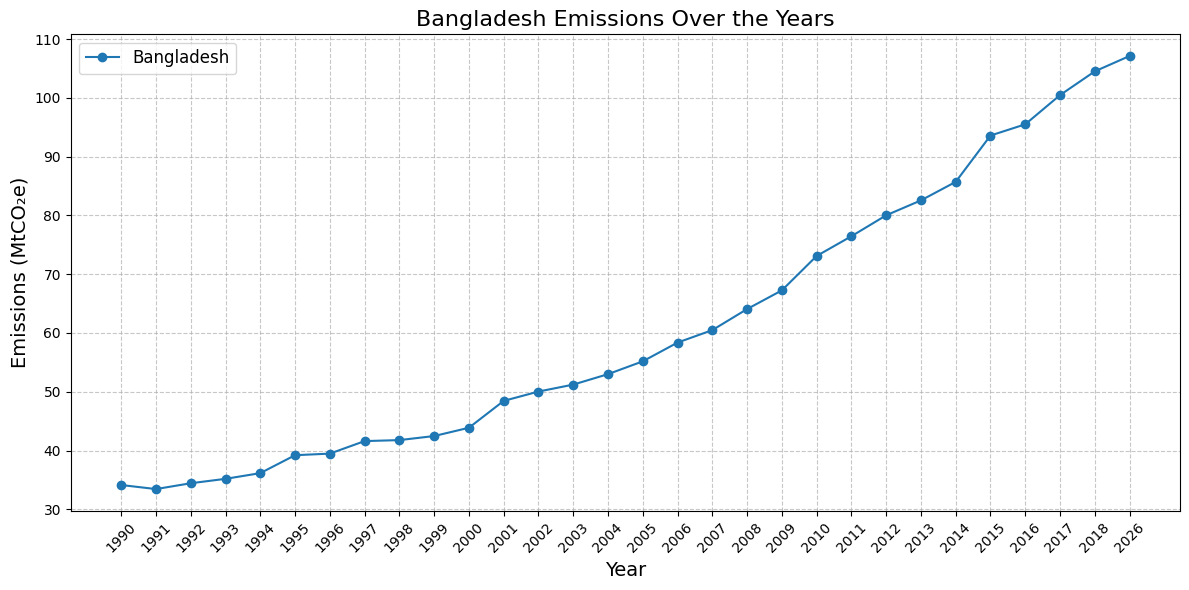

In [ ]:
# Getting best model on Least MAE
if (np.mean(lstm_history.history['mae']) <= prophet_mae and np.mean(lstm_history.history['mae']) <= arima_mae and
    np.mean(lstm_history.history['mae']) <= bi_lstm_test_mae and np.mean(lstm_history.history['mae']) <= sarima_mae and
    np.mean(lstm_history.history['mae']) <= np.mean(gru_history.history['mae'])):
    prediction = predicted_emission
    variable = "LSTM"
elif (prophet_mae <= np.mean(lstm_history.history['mae']) and prophet_mae <= arima_mae and
      prophet_mae <= bi_lstm_test_mae and prophet_mae <= sarima_mae and
      prophet_mae <= np.mean(gru_history.history['mae'])):
    prediction = prophet_prediction
    variable = "Prophet"
elif (arima_mae <= np.mean(lstm_history.history['mae']) and arima_mae <= prophet_mae and
      arima_mae <= bi_lstm_test_mae and arima_mae <= sarima_mae and
      arima_mae <= np.mean(gru_history.history['mae'])):
    prediction = arima_prediction
    variable = "ARIMA"
elif (bi_lstm_test_mae <= np.mean(lstm_history.history['mae']) and bi_lstm_test_mae <= prophet_mae and
      bi_lstm_test_mae <= arima_mae and bi_lstm_test_mae <= sarima_mae and
      bi_lstm_test_mae <= np.mean(gru_history.history['mae'])):
    prediction = predicted_emission_bilstm
    variable = "Bi-LSTM"
elif (sarima_mae <= np.mean(lstm_history.history['mae']) and sarima_mae <= prophet_mae and
      sarima_mae <= arima_mae and sarima_mae <= bi_lstm_test_mae and
      sarima_mae <= np.mean(gru_history.history['mae'])):
    prediction = sarima_prediction
    variable = "SARIMA"
else:
    prediction = predicted_emission_gru
    variable = "GRU"


print(f"{variable} out performs other models.")
# Filtering data for the United States
ct_data = data[data['Country'] == country_name]

# Extracting years and corresponding emissions
year1 = [col for col in ct_data.columns if col.isdigit()]
emission1 = ct_data[year1].iloc[0]

# Converting years and emissions to lists for modification
year1 = list(year1)
emission1 = list(emission1)

# Manually adding an extra year of emission
def add_extra_year(year, emission_value):
    year1.append(str(year))
    emission1.append(emission_value)


add_extra_year(target_year, prediction)

year1, emission1 = zip(*sorted(zip(year1, emission1)))
# plotting the data
plt.figure(figsize=(12, 6))
plt.plot(year1, emission1, marker='o', linestyle='-', label=country_name)
plt.title(f'{country_name} Emissions Over the Years', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Emissions (MtCO₂e)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Zone Check

In [ ]:
# using the latest available year (2018) for emission data
emissions = data['2018']

# setting thresholds based on percentiles
percentiles = {
    "Clean Zone": emissions.quantile(0.1),
    "Green Zone": emissions.quantile(0.25),
    "Safe Zone": emissions.quantile(0.4),
    "Stable Zone": emissions.quantile(0.5),
    "Warning Zone": emissions.quantile(0.6),
    "Caution Zone": emissions.quantile(0.75),
    "Risk Zone": emissions.quantile(0.85),
    "Danger Zone": emissions.quantile(0.9),
    "Severe Zone": emissions.quantile(0.95),
    "Critical Zone": emissions.max()
}

# Defining the risk levels based on the thresholds
def determine_risk_level(emission_value):
    if emission_value <= percentiles['Clean Zone']:
        return "Clean Zone"
    elif emission_value <= percentiles['Green Zone']:
        return "Green Zone"
    elif emission_value <= percentiles['Safe Zone']:
        return "Safe Zone"
    elif emission_value <= percentiles['Stable Zone']:
        return "Stable Zone"
    elif emission_value <= percentiles['Warning Zone']:
        return "Warning Zone"
    elif emission_value <= percentiles['Caution Zone']:
        return "Caution Zone"
    elif emission_value <= percentiles['Risk Zone']:
        return "Risk Zone"
    elif emission_value <= percentiles['Danger Zone']:
        return "Danger Zone"
    elif emission_value <= percentiles['Severe Zone']:
        return "Severe Zone"
    else:
        return "Critical Zone"



risk_level = determine_risk_level(prediction)
print(f"The CO2 emission rate of {prediction} MtCO₂e falls under the '{risk_level}' category.")



The CO2 emission rate of 107.11321405649186 MtCO₂e falls under the 'Risk Zone' category.


# Final output plant name

In [ ]:
if risk_level=="Caution Zone" or "Risk Zone" or "Danger Zone" or "Severe Zone" or "Critical Zone":
  # Loading datasets
  distances_df = pd.read_csv('/content/dist_cepii.csv')
  plants_df = pd.read_csv('/content/CCS_Map_Data_Filled_Combustion_Separation.csv')

  def calculate_distances(input_country_name):
      # Step 1: Extracting the  unique ICO codes for countries from `plants_df`
      plant_countries = plants_df['Country Location'].unique()

      # Ensuring that `distances_df` contains required columns
      if not {'iso_o', 'iso_d', 'dist'}.issubset(distances_df.columns):
          raise ValueError("The 'dist_cepii.csv' file is missing required columns: 'iso_o', 'iso_d', 'dist'.")

      # Manually mapping the  input country names to ICO codes only if `country_name` is unavailable
      # Replacing this dictionary with actual mapping
      country_to_ico = {
      "Afghanistan": "AFG",
      "Albania": "ALB",
      "Algeria": "DZA",
      "Andorra": "AND",
      "Angola": "AGO",
      "Antigua and Barbuda": "ATG",
      "Argentina": "ARG",
      "Armenia": "ARM",
      "Australia": "AUS",
      "Austria": "AUT",
      "Azerbaijan": "AZE",
      "Bahamas": "BHS",
      "Bahrain": "BHR",
      "Bangladesh": "BGD",
      "Barbados": "BRB",
      "Belarus": "BLR",
      "Belgium": "BEL",
      "Belize": "BLZ",
      "Benin": "BEN",
      "Bhutan": "BTN",
      "Bolivia": "BOL",
      "Bosnia and Herzegovina": "BIH",
      "Botswana": "BWA",
      "Brazil": "BRA",
      "Brunei": "BRN",
      "Bulgaria": "BGR",
      "Burkina Faso": "BFA",
      "Burundi": "BDI",
      "Cabo Verde": "CPV",
      "Cambodia": "KHM",
      "Cameroon": "CMR",
      "Canada": "CAN",
      "Central African Republic": "CAF",
      "Chad": "TCD",
      "Chile": "CHL",
      "China": "CHN",
      "Colombia": "COL",
      "Comoros": "COM",
      "Congo (Congo-Brazzaville)": "COG",
      "Congo (Congo-Kinshasa)": "COD",
      "Costa Rica": "CRI",
      "Croatia": "HRV",
      "Cuba": "CUB",
      "Cyprus": "CYP",
      "Czech Republic (Czechia)": "CZE",
      "Denmark": "DNK",
      "Djibouti": "DJI",
      "Dominica": "DMA",
      "Dominican Republic": "DOM",
      "Ecuador": "ECU",
      "Egypt": "EGY",
      "El Salvador": "SLV",
      "Equatorial Guinea": "GNQ",
      "Eritrea": "ERI",
      "Estonia": "EST",
      "Eswatini (fmr. Swaziland)": "SWZ",
      "Ethiopia": "ETH",
      "Fiji": "FJI",
      "Finland": "FIN",
      "France": "FRA",
      "Gabon": "GAB",
      "Gambia": "GMB",
      "Georgia": "GEO",
      "Germany": "DEU",
      "Ghana": "GHA",
      "Greece": "GRC",
      "Grenada": "GRD",
      "Guatemala": "GTM",
      "Guinea": "GIN",
      "Guinea-Bissau": "GNB",
      "Guyana": "GUY",
      "Haiti": "HTI",
      "Honduras": "HND",
      "Hungary": "HUN",
      "Iceland": "ISL",
      "India": "IND",
      "Indonesia": "IDN",
      "Iran": "IRN",
      "Iraq": "IRQ",
      "Ireland": "IRL",
      "Israel": "ISR",
      "Italy": "ITA",
      "Jamaica": "JAM",
      "Japan": "JPN",
      "Jordan": "JOR",
      "Kazakhstan": "KAZ",
      "Kenya": "KEN",
      "Kiribati": "KIR",
      "Kuwait": "KWT",
      "Kyrgyzstan": "KGZ",
      "Laos": "LAO",
      "Latvia": "LVA",
      "Lebanon": "LBN",
      "Lesotho": "LSO",
      "Liberia": "LBR",
      "Libya": "LBY",
      "Liechtenstein": "LIE",
      "Lithuania": "LTU",
      "Luxembourg": "LUX",
      "Madagascar": "MDG",
      "Malawi": "MWI",
      "Malaysia": "MYS",
      "Maldives": "MDV",
      "Mali": "MLI",
      "Malta": "MLT",
      "Marshall Islands": "MHL",
      "Mauritania": "MRT",
      "Mauritius": "MUS",
      "Mexico": "MEX",
      "Micronesia": "FSM",
      "Moldova": "MDA",
      "Monaco": "MCO",
      "Mongolia": "MNG",
      "Montenegro": "MNE",
      "Morocco": "MAR",
      "Mozambique": "MOZ",
      "Myanmar (Burma)": "MMR",
      "Namibia": "NAM",
      "Nauru": "NRU",
      "Nepal": "NPL",
      "Netherlands": "NLD",
      "New Zealand": "NZL",
      "Nicaragua": "NIC",
      "Niger": "NER",
      "Nigeria": "NGA",
      "North Korea": "PRK",
      "North Macedonia": "MKD",
      "Norway": "NOR",
      "Oman": "OMN",
      "Pakistan": "PAK",
      "Palau": "PLW",
      "Palestine State": "PSE",
      "Panama": "PAN",
      "Papua New Guinea": "PNG",
      "Paraguay": "PRY",
      "Peru": "PER",
      "Philippines": "PHL",
      "Poland": "POL",
      "Portugal": "PRT",
      "Qatar": "QAT",
      "Romania": "ROU",
      "Russia": "RUS",
      "Rwanda": "RWA",
      "Saint Kitts and Nevis": "KNA",
      "Saint Lucia": "LCA",
      "Saint Vincent and the Grenadines": "VCT",
      "Samoa": "WSM",
      "San Marino": "SMR",
      "Sao Tome and Principe": "STP",
      "Saudi Arabia": "SAU",
      "Senegal": "SEN",
      "Serbia": "SRB",
      "Seychelles": "SYC",
      "Sierra Leone": "SLE",
      "Singapore": "SGP",
      "Slovakia": "SVK",
      "Slovenia": "SVN",
      "Solomon Islands": "SLB",
      "Somalia": "SOM",
      "South Africa": "ZAF",
      "South Korea": "KOR",
      "South Sudan": "SSD",
      "Spain": "ESP",
      "Sri Lanka": "LKA",
      "Sudan": "SDN",
      "Suriname": "SUR",
      "Sweden": "SWE",
      "Switzerland": "CHE",
      "Syria": "SYR",
      "Tajikistan": "TJK",
      "Tanzania": "TZA",
      "Thailand": "THA",
      "Timor-Leste": "TLS",
      "Togo": "TGO",
      "Tonga": "TON",
      "Trinidad and Tobago": "TTO",
      "Tunisia": "TUN",
      "Turkey": "TUR",
      "Turkmenistan": "TKM",
      "Tuvalu": "TUV",
      "Uganda": "UGA",
      "Ukraine": "UKR",
      "United Arab Emirates": "ARE",
      "United Kingdom": "GBR",
      "United States": "USA",
      "Uruguay": "URY",
      "Uzbekistan": "UZB",
      "Vanuatu": "VUT",
      "Vatican City": "VAT",
      "Venezuela": "VEN",
      "Vietnam": "VNM",
      "Yemen": "YEM",
      "Zambia": "ZMB",
      "Zimbabwe": "ZWE"
      }


      # country name validation
      input_country_ico = country_to_ico.get(input_country_name)
      if input_country_ico is None:
          raise ValueError(f"The input country '{input_country_name}' is not mapped to an ICO code. Add it to the mapping.")

      # Step 2: Filtering distances for input country
      input_country_distances = distances_df[distances_df['iso_o'] == input_country_ico]

      # Step 3:plant locations to ICO codes mapping
      plants_df['Country ICO'] = plants_df['Country Location'].map(country_to_ico)

      # Step 4:merging distance with plant data
      plants_with_distances = pd.merge(
          plants_df,
          input_country_distances[['iso_d', 'dist']],
          left_on='Country ICO',
          right_on='iso_d',
          how='inner'
      )

      # Step 5:originate columns and rename
      plants_with_distances.rename(
          columns={
              'dist': f'Distance from {input_country_name} (km)',
              'Size or Capture Amount/unit base power': 'Capture Amount/Unit Power'
          },
          inplace=True
      )
      output_columns = [
          'Project ID', 'Project Name', 'Plant Name', 'Plant Status', 'Country Location','Latitude','Longitude', 'Cost','Currency Name',
          f'Distance from {input_country_name} (km)', 'Capture Amount/Unit Power','Power or Capture Unit', 'Scope Name', 'Project Type'
      ]
      output_df = plants_with_distances[output_columns]

      return output_df


  output_dataset = calculate_distances(country_name)

  # result to save in csv
  output_dataset.to_csv('Output_Dataset.csv', index=False)
  print("Output dataset has been saved as 'Output_Dataset.csv'.")
else:
  print("No action required.")

Output dataset has been saved as 'Output_Dataset.csv'.


In [ ]:

# Read the CSV file
df = pd.read_csv('Output_Dataset.csv')

# Define currency conversion rates to USD (based on average historical rates)
conversion_rates = {
    'US Dollar': 1.0,
    'Australian Dollar': 0.75,
    'Canadian Dollar': 0.80,
    'Euros': 1.18,
    'British Pound': 1.35,
    'Norwegian Kroner': 0.12,
    'Danish Krone': 0.16,
    'Japenese Yen': 0.009,
    'Chinese Yuan': 0.15,
    'Brazilian Real': 0.20
}

# Function to convert cost to USD
def convert_to_usd(row):
    if pd.isna(row['Cost']) or row['Cost'] == 0:
        return row['Cost']

    currency = row['Currency Name']
    if currency in conversion_rates:
        return row['Cost'] * conversion_rates[currency]
    return row['Cost']

# Convert costs to USD
df['Cost'] = df.apply(convert_to_usd, axis=1)

# Update all currency names to US Dollar
df['Currency Name'] = 'US Dollar'

# Save the updated dataset
df.to_csv('Output_Dataset_USD.csv', index=False)
print("Conversion completed. New file saved as 'Output_Dataset_USD.csv'")

Conversion completed. New file saved as 'Output_Dataset_USD.csv'


In [ ]:
# Read the CSV file
df = pd.read_csv('Output_Dataset_USD.csv')

# Create distance column name dynamically
distance_col = f"Distance from {country_name} (km)"

# Create a list to store results for CSV export
results_for_csv = []

# Create a function to print plant details and collect data for CSV
def print_plant_details(plants, category):
    print(f"\n{category}:")
    print("-" * 100)
    for _, plant in plants.iterrows():
        # Print details
        print(f"Project Name: {plant['Project Name']}")
        print(f"Plant Name: {plant['Plant Name']}")
        print(f"Country: {plant['Country Location']}")
        print(f"Latitude: {plant['Latitude']}")
        print(f"Longitude: {plant['Longitude']}")
        print(f"Distance: {plant[distance_col]:.2f} km")
        print(f"Cost: ${plant['Cost']:,.2f}")
        if 'Capture Amount/Unit Power' in plant and pd.notna(plant['Capture Amount/Unit Power']):
            print(f"Capture Amount: {plant['Capture Amount/Unit Power']} {plant['Power or Capture Unit']}")
        print("-" * 100)

        # Collect data for CSV
        results_for_csv.append({
            'Category': category,
            'Project Name': plant['Project Name'],
            'Plant Name': plant['Plant Name'],
            'Country': plant['Country Location'],
            'Latitude': plant['Latitude'],
            'Longitude': plant['Longitude'],
            'Distance (km)': round(plant[distance_col], 2),
            'Cost (USD)': plant['Cost'],
            'Capture Amount': plant['Capture Amount/Unit Power'] if pd.notna(plant['Capture Amount/Unit Power']) else '',
            'Unit': plant['Power or Capture Unit'] if pd.notna(plant['Power or Capture Unit']) else ''
        })

# Filter for existing plants
existing_plants = df[df['Plant Status'] == 'Existing']
international_plants = existing_plants[existing_plants['Scope Name'] == 'International']

# 1. Three plants with lowest distance from input country
nearest_plants = international_plants.nsmallest(3, distance_col)
print_plant_details(nearest_plants, f"Three Plants with Lowest Distance from {country_name}")

# 2. Three plants with lowest cost (excluding zero cost)
lowest_cost = international_plants[international_plants['Cost'] > 0].nsmallest(3, 'Cost')
print_plant_details(lowest_cost, "Three Plants with Lowest Cost (Excluding Zero Cost)")

# 3. Three plants with maximum storage capacity
storage_plants = international_plants[pd.to_numeric(international_plants['Capture Amount/Unit Power'], errors='coerce').notna()]
max_storage = storage_plants.nlargest(3, 'Capture Amount/Unit Power')
print_plant_details(max_storage, "Three Plants with Maximum Storage/Capture Capacity")

# Export results to CSV
results_df = pd.DataFrame(results_for_csv)
output_file = 'CCS_Plants_Output(PowerBi).csv'
results_df.to_csv(output_file, index=False)
print(f"\nResults have been exported to {output_file}")


Three Plants with Lowest Distance from Bangladesh:
----------------------------------------------------------------------------------------------------
Project Name: Phulpur Urea Plant CO2 Recovery project
Plant Name: CO2 Recovery (CDR) IFFCO Aonla Unit
Country: India
Latitude: 28.276608
Longitude: 79.168361
Distance: 1421.94 km
Cost: $0.00
----------------------------------------------------------------------------------------------------
Project Name: Koyali CCUS project
Plant Name: Koyali refinery
Country: India
Latitude: 22.36606
Longitude: 73.12899
Distance: 1421.94 km
Cost: $0.00
----------------------------------------------------------------------------------------------------
Project Name: Petronas Gas Processing Capture Project
Plant Name: Petronas fertilizer plant
Country: Malaysia
Latitude: 5.83516
Longitude: 100.49881
Distance: 2593.44 km
Cost: $0.00
----------------------------------------------------------------------------------------------------

Three Plants with Low

In [ ]:
#Filtering all
df = pd.read_csv("Output_Dataset_USD.csv")

distance_col = f"Distance from {country_name} (km)"

# Updated filter logic for scope
mask_same = (df["Country Location"] == country_name) & (df["Scope Name"].isin(["National", "International"]))
mask_diff = (df["Country Location"] != country_name) & (df["Scope Name"] == "International")
filtered = df[(df["Plant Status"] == "Existing") &
              (df["Cost"] > 0) &
              (mask_same | mask_diff)]

# Only keep relevant columns
filtered = filtered[["Project ID", "Project Name", "Plant Name", "Country Location", "Scope Name", distance_col,"Latitude","Longitude","Cost"]].dropna(subset=["Cost"])
filtered = filtered.reset_index(drop=True)
filtered

,Project ID,Project Name,Plant Name,Country Location,Scope Name,Distance from Bangladesh (km),Latitude,Longitude,Cost
0,412,Lehigh Cement Feasibility Study of Full-Scale ...,"Lehigh's Edmonton, Alberta cement plant",Canada,International,12464.920,53.579909,-113.600940,1.120000e+06
1,2,In Salah Gas Storage Project,In Salah Gas Processing Plant,Algeria,International,8242.789,27.185919,2.497676,2.700000e+09
2,3,CS Energy Callide Oxyfuels Project,Callide A Power Station,Australia,International,9077.625,-24.341219,150.608521,1.837500e+08
3,5,CSIRO Transportable Capture Unit Tarong (Queen...,Tarong Power Station,Australia,International,9077.625,-26.783583,151.915120,3.750000e+06
4,6,CSIRO Transportable Capture Unit Loy Yang (Vic...,Loy Yang Power Plant,Australia,International,9077.625,-38.235054,146.571747,3.750000e+06
5,9,Gorgon Project,CO2 Separated during LNG process,Australia,International,9077.625,-20.776909,115.460907,4.050000e+10
6,10,Hazelwood Post-Combustion 2030 Project,Hazelwood Power Station,Australia,International,9077.625,-38.272976,146.391785,2.500500e+08
7,11,HRL IDGCC Project,HRL IDGCC Plant,Australia,International,9077.625,-38.255862,146.592067,5.625000e+08
8,14,Moomba Cooper Basin Carbon Storage Project,Santos Moomba Facility,Australia,International,9077.625,-28.113216,140.206906,5.600000e+08
9,20,Alberta Carbon Trunk Line,North West Upgrading Inc. and Agrium Inc,Canada,International,12464.920,53.788356,-112.961851,6.000000e+08


In [ ]:
# 2. Apply TOPSIS
def topsis(df, cost_col, dist_col):
    data = df[[cost_col, dist_col]].astype(float)
    # Normalize
    norm = np.sqrt((data ** 2).sum())
    normed = data / norm
    # Weights (equal)
    weights = np.array([0.5, 0.5])
    weighted = normed * weights
    # Ideal and anti-ideal
    ideal = weighted.min()
    anti_ideal = weighted.max()
    # Distance to ideal and anti-ideal
    d_pos = np.sqrt(((weighted - ideal) ** 2).sum(axis=1))
    d_neg = np.sqrt(((weighted - anti_ideal) ** 2).sum(axis=1))
    score = d_neg / (d_pos + d_neg)
    idx = score.idxmax()
    return df.loc[idx]

selected_topsis = topsis(filtered, "Cost", distance_col)
print("TOPSIS selected plant:")
print(selected_topsis)
# Save to CSV
selected_topsis.to_frame().T.to_csv("topsis_selected.csv", index=False)

TOPSIS selected plant:
Project ID                                                               44
Project Name                     Post-Combustion Capture Project in Beijing
Plant Name                        Huaneng Beijing Co-Generation Power Plant
Country Location                                                      China
Scope Name                                                    International
Distance from Bangladesh (km)                                      3036.238
Latitude                                                          39.886528
Longitude                                                          116.5325
Cost                                                              4000000.0
Name: 14, dtype: object


In [ ]:
# 3. Apply Weighted Sum Model (WSM)
def wsm(df, cost_col, dist_col):
    data = df[[cost_col, dist_col]].astype(float)
    # Normalize (min-max)
    normed = (data - data.min()) / (data.max() - data.min())
    # Weights (equal)
    weights = np.array([0.5, 0.5])
    score = (normed * weights).sum(axis=1)
    idx = score.idxmin()  # Lower is better
    return df.loc[idx]

selected_wsm = wsm(filtered, "Cost", distance_col)
print("WSM selected plant:")
print(selected_wsm)
# Save to CSV
selected_wsm.to_frame().T.to_csv("wsm_selected.csv", index=False)

WSM selected plant:
Project ID                                                               44
Project Name                     Post-Combustion Capture Project in Beijing
Plant Name                        Huaneng Beijing Co-Generation Power Plant
Country Location                                                      China
Scope Name                                                    International
Distance from Bangladesh (km)                                      3036.238
Latitude                                                          39.886528
Longitude                                                          116.5325
Cost                                                              4000000.0
Name: 14, dtype: object


In [ ]:
# 4. Apply VIKOR
def vikor(df, cost_col, dist_col, v=0.5):
    data = df[[cost_col, dist_col]].astype(float)
    f_star = data.min()
    f_minus = data.max()
    S = ((f_star - data) / (f_star - f_minus)).abs().sum(axis=1)
    R = ((f_star - data) / (f_star - f_minus)).abs().max(axis=1)
    S_star, S_minus = S.min(), S.max()
    R_star, R_minus = R.min(), R.max()
    Q = v * (S - S_star) / (S_minus - S_star + 1e-9) + (1 - v) * (R - R_star) / (R_minus - R_star + 1e-9)
    idx = Q.idxmin()
    return df.loc[idx]

selected_vikor = vikor(filtered, "Cost", distance_col)
print("VIKOR selected plant:")
print(selected_vikor)
# Save to CSV
selected_vikor.to_frame().T.to_csv("vikor_selected.csv", index=False)

VIKOR selected plant:
Project ID                                                               44
Project Name                     Post-Combustion Capture Project in Beijing
Plant Name                        Huaneng Beijing Co-Generation Power Plant
Country Location                                                      China
Scope Name                                                    International
Distance from Bangladesh (km)                                      3036.238
Latitude                                                          39.886528
Longitude                                                          116.5325
Cost                                                              4000000.0
Name: 14, dtype: object
